In [463]:
import pandas as pd
import numpy as np
import matplotlib
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import joblib

In [464]:
weather = pd.read_csv("../data/thessaloniki_weather_raw.csv")

In [465]:
weather

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,PRCP_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
0,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,1964-01-03,NaN,NaN,NaN,NaN,1.9,"H,,S",3.9,",,S",1.1,",,S"
1,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,1964-01-06,NaN,NaN,NaN,NaN,-0.2,"H,,S",6.1,",,S",-2.8,",,S"
2,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,1964-01-08,NaN,NaN,NaN,NaN,0.8,"H,,S",7.8,",,S",-5.0,",,S"
3,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,1964-01-09,NaN,NaN,NaN,NaN,2.4,"H,,S",7.2,",,S",-1.1,",,S"
4,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,1964-01-13,NaN,NaN,NaN,NaN,-1.2,"H,,S",10.0,",,S",-5.0,",,S"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21206,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,2025-08-20,0.0,",,S",NaN,NaN,25.3,"H,,S",30.4,",,S",NaN,NaN
21207,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,2025-08-21,0.0,",,S",NaN,NaN,25.9,"H,,S",NaN,NaN,20.0,",,S"
21208,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,2025-08-22,0.0,",,S",NaN,NaN,26.6,"H,,S",NaN,NaN,NaN,NaN
21209,GRM00016622,"MAKEDONIA, GR",40.52,22.971,6.7,2025-08-23,0.0,",,S",NaN,NaN,28.0,"H,,S",32.0,",,S",NaN,NaN


In [466]:
weather.shape

(21211, 16)

In [467]:
weather.dtypes

STATION                str
NAME                   str
LATITUDE           float64
LONGITUDE          float64
ELEVATION          float64
DATE                   str
PRCP               float64
PRCP_ATTRIBUTES        str
SNWD               float64
SNWD_ATTRIBUTES        str
TAVG               float64
TAVG_ATTRIBUTES        str
TMAX               float64
TMAX_ATTRIBUTES        str
TMIN               float64
TMIN_ATTRIBUTES        str
dtype: object

In [468]:
weather.isna().sum()

STATION                0
NAME                   0
LATITUDE               0
LONGITUDE              0
ELEVATION              0
DATE                   0
PRCP                5209
PRCP_ATTRIBUTES     5209
SNWD               21145
SNWD_ATTRIBUTES    21145
TAVG                   0
TAVG_ATTRIBUTES        0
TMAX                6894
TMAX_ATTRIBUTES     6894
TMIN                8787
TMIN_ATTRIBUTES     8787
dtype: int64

In [469]:
(weather.isna().mean() * 100).round(1)

STATION             0.0
NAME                0.0
LATITUDE            0.0
LONGITUDE           0.0
ELEVATION           0.0
DATE                0.0
PRCP               24.6
PRCP_ATTRIBUTES    24.6
SNWD               99.7
SNWD_ATTRIBUTES    99.7
TAVG                0.0
TAVG_ATTRIBUTES     0.0
TMAX               32.5
TMAX_ATTRIBUTES    32.5
TMIN               41.4
TMIN_ATTRIBUTES    41.4
dtype: float64

In [470]:
weather.describe()

,LATITUDE,LONGITUDE,ELEVATION,PRCP,SNWD,TAVG,TMAX,TMIN
count,2.121100e+04,2.121100e+04,2.121100e+04,16002.000000,66.000000,21211.000000,14317.000000,12424.000000
mean,4.052000e+01,2.297100e+01,6.700000e+00,1.302393,358.424242,15.396940,20.649843,10.313989
std,7.105595e-15,3.552797e-15,1.776399e-15,5.102234,412.787264,7.831745,8.730691,7.302387
min,4.052000e+01,2.297100e+01,6.700000e+00,0.000000,10.000000,-5.900000,-3.900000,-12.800000
25%,4.052000e+01,2.297100e+01,6.700000e+00,0.000000,20.000000,8.900000,13.200000,4.600000
50%,4.052000e+01,2.297100e+01,6.700000e+00,0.000000,145.000000,15.100000,20.400000,10.600000
75%,4.052000e+01,2.297100e+01,6.700000e+00,0.000000,749.000000,22.300000,28.200000,16.600000
max,4.052000e+01,2.297100e+01,6.700000e+00,154.900000,1199.000000,32.900000,44.000000,27.000000


In [471]:
weather["DATE"].duplicated().sum()

np.int64(0)

In [472]:
weather["DATE"] = pd.to_datetime(weather["DATE"])

In [473]:
weather["DATE"].dt.year.value_counts().sort_index()

DATE
1964    274
1965    359
1966    212
1967    348
1968    366
1969    365
1970    364
1971     90
1973    365
1974    350
1975    364
1976    366
1977    365
1978    365
1979    365
1980    366
1981    365
1982    365
1983    365
1984    366
1985    365
1986    365
1987    365
1988    366
1989    365
1990    365
1991    365
1992    366
1993    365
1994    365
1995    365
1996    366
1997    365
1998    365
1999    364
2000    366
2001    365
2002    365
2003    365
2004    366
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    362
2022    365
2023    365
2024    355
2025    236
Name: count, dtype: int64

In [474]:
weather["TMAX"].isna().groupby(weather["DATE"].dt.year).sum()

DATE
1964      3
1965      4
1966     10
1967      6
1968     13
1969     79
1970     31
1971      0
1973     42
1974     43
1975     47
1976     42
1977     32
1978     38
1979     48
1980     43
1981     36
1982     93
1983     78
1984     76
1985    114
1986     69
1987    102
1988    106
1989     82
1990    117
1991    110
1992    122
1993    113
1994     98
1995    105
1996    104
1997     71
1998    117
1999    120
2000    205
2001    173
2002    102
2003    135
2004    155
2006    126
2007    131
2008    130
2009    156
2010    176
2011    178
2012    191
2013    295
2014    355
2015    196
2016    194
2017    218
2018    217
2019    179
2020    186
2021    186
2022    204
2023    177
2024    189
2025    126
Name: TMAX, dtype: int64

In [475]:
weather = pd.read_csv("../data/thessaloniki_openmeteo_raw.csv", skiprows=3)

In [476]:
weather

,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),relative_humidity_2m_max (%),relative_humidity_2m_min (%)
0,1950-01-01,NaN,5.2,0.3,NaN,98,87
1,1950-01-02,-0.5,1.9,-3.3,85.0,98,67
2,1950-01-03,-1.6,2.1,-6.7,90.0,99,81
3,1950-01-04,1.6,6.2,-1.6,75.0,91,57
4,1950-01-05,0.7,6.6,-3.3,72.0,84,52
...,...,...,...,...,...,...,...
28012,2026-09-11,26.1,31.1,20.9,75.0,100,45
28013,2026-09-12,26.1,31.4,22.5,75.0,99,49
28014,2026-09-13,23.3,27.5,19.6,46.0,72,25
28015,2026-09-14,22.4,27.3,17.7,44.0,68,27


In [477]:
weather.dtypes

time                                 str
temperature_2m_mean (°C)         float64
temperature_2m_max (°C)          float64
temperature_2m_min (°C)          float64
relative_humidity_2m_mean (%)    float64
relative_humidity_2m_max (%)       int64
relative_humidity_2m_min (%)       int64
dtype: object

In [478]:
weather.isna().sum()

time                             0
temperature_2m_mean (°C)         1
temperature_2m_max (°C)          0
temperature_2m_min (°C)          0
relative_humidity_2m_mean (%)    1
relative_humidity_2m_max (%)     0
relative_humidity_2m_min (%)     0
dtype: int64

In [479]:
weather["time"] = pd.to_datetime(weather["time"])

In [480]:
weather["time"].dt.year.value_counts().sort_index()

time
1950    365
1951    365
1952    366
1953    365
1954    365
       ... 
2022    365
2023    365
2024    366
2025    365
2026    258
Name: count, Length: 77, dtype: int64

In [481]:
weather["time"].duplicated().sum()

np.int64(0)

In [482]:
weather.describe()

,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),relative_humidity_2m_mean (%),relative_humidity_2m_max (%),relative_humidity_2m_min (%)
count,28017,28016.000000,28017.000000,28017.000000,28016.000000,28017.000000,28017.000000
mean,1988-05-09 00:00:00,15.549036,19.823864,11.559753,71.073529,88.469643,51.695613
min,1950-01-01 00:00:00,-10.200000,-7.000000,-16.100000,28.000000,38.000000,10.000000
25%,1969-03-06 00:00:00,8.600000,12.700000,5.100000,62.000000,83.000000,40.000000
50%,1988-05-09 00:00:00,15.400000,19.700000,11.500000,72.000000,90.000000,51.000000
75%,2007-07-13 00:00:00,22.900000,27.400000,18.500000,81.000000,96.000000,63.000000
max,2026-09-15 00:00:00,35.300000,43.700000,28.300000,98.000000,100.000000,96.000000
std,NaN,8.314319,8.728002,7.882294,12.625574,9.435450,15.638813


In [483]:
weather = weather.rename(columns={"time": "date", "temperature_2m_mean (°C)": "temp_c_avg", "temperature_2m_max (°C)": "temp_c_max", "temperature_2m_min (°C)": "temp_c_min", "relative_humidity_2m_mean (%)": "humidity_avg", "relative_humidity_2m_max (%)": "humidity_max", "relative_humidity_2m_min (%)": "humidity_min"})
weather

,date,temp_c_avg,temp_c_max,temp_c_min,humidity_avg,humidity_max,humidity_min
0,1950-01-01,NaN,5.2,0.3,NaN,98,87
1,1950-01-02,-0.5,1.9,-3.3,85.0,98,67
2,1950-01-03,-1.6,2.1,-6.7,90.0,99,81
3,1950-01-04,1.6,6.2,-1.6,75.0,91,57
4,1950-01-05,0.7,6.6,-3.3,72.0,84,52
...,...,...,...,...,...,...,...
28012,2026-09-11,26.1,31.1,20.9,75.0,100,45
28013,2026-09-12,26.1,31.4,22.5,75.0,99,49
28014,2026-09-13,23.3,27.5,19.6,46.0,72,25
28015,2026-09-14,22.4,27.3,17.7,44.0,68,27


In [484]:
weather = weather.dropna()
weather.isna().sum()

date            0
temp_c_avg      0
temp_c_max      0
temp_c_min      0
humidity_avg    0
humidity_max    0
humidity_min    0
dtype: int64

In [485]:
weather = weather.set_index("date")

In [486]:
weather.to_csv("../data/thessaloniki_openmeteo_clean.csv")

In [487]:
core_weather = pd.read_csv("../data/thessaloniki_openmeteo_clean.csv", index_col="date", parse_dates=True )

In [488]:
#Since we want to predict the next week, 7 targets are set to next 7 days of each day
core_weather["target1_max"] = core_weather.shift(-1)["temp_c_max"]
core_weather["target1_min"] = core_weather.shift(-1)["temp_c_min"]

core_weather["target2_max"] = core_weather.shift(-2)["temp_c_max"]
core_weather["target2_min"] = core_weather.shift(-2)["temp_c_min"]

core_weather["target3_max"] = core_weather.shift(-3)["temp_c_max"]
core_weather["target3_min"] = core_weather.shift(-3)["temp_c_min"]

core_weather["target4_max"] = core_weather.shift(-4)["temp_c_max"]
core_weather["target4_min"] = core_weather.shift(-4)["temp_c_min"]

core_weather["target5_max"] = core_weather.shift(-5)["temp_c_max"]
core_weather["target5_min"] = core_weather.shift(-5)["temp_c_min"]

core_weather["target6_max"] = core_weather.shift(-6)["temp_c_max"]
core_weather["target6_min"] = core_weather.shift(-6)["temp_c_min"]

core_weather["target7_max"] = core_weather.shift(-7)["temp_c_max"]
core_weather["target7_min"] = core_weather.shift(-7)["temp_c_min"]

core_weather = core_weather.iloc[:-7, :].copy()
core_weather

,temp_c_avg,temp_c_max,temp_c_min,humidity_avg,humidity_max,humidity_min,target1_max,target1_min,target2_max,target2_min,target3_max,target3_min,target4_max,target4_min,target5_max,target5_min,target6_max,target6_min,target7_max,target7_min
date,,,,,,,,,,,,,,,,,,,,
1950-01-02,-0.5,1.9,-3.3,85.0,98,67,2.1,-6.7,6.2,-1.6,6.6,-3.3,7.0,-2.1,9.5,-0.9,8.7,-0.6,9.6,0.7
1950-01-03,-1.6,2.1,-6.7,90.0,99,81,6.2,-1.6,6.6,-3.3,7.0,-2.1,9.5,-0.9,8.7,-0.6,9.6,0.7,12.1,1.7
1950-01-04,1.6,6.2,-1.6,75.0,91,57,6.6,-3.3,7.0,-2.1,9.5,-0.9,8.7,-0.6,9.6,0.7,12.1,1.7,5.9,0.9
1950-01-05,0.7,6.6,-3.3,72.0,84,52,7.0,-2.1,9.5,-0.9,8.7,-0.6,9.6,0.7,12.1,1.7,5.9,0.9,0.4,-4.3
1950-01-06,1.9,7.0,-2.1,72.0,85,59,9.5,-0.9,8.7,-0.6,9.6,0.7,12.1,1.7,5.9,0.9,0.4,-4.3,-3.2,-10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-04,27.1,31.4,21.7,52.0,80,28,32.0,22.6,34.3,22.2,29.9,22.7,26.7,20.8,28.4,20.0,30.1,20.8,31.1,20.9
2026-09-05,26.8,32.0,22.6,55.0,81,31,34.3,22.2,29.9,22.7,26.7,20.8,28.4,20.0,30.1,20.8,31.1,20.9,31.4,22.5
2026-09-06,28.3,34.3,22.2,54.0,86,28,29.9,22.7,26.7,20.8,28.4,20.0,30.1,20.8,31.1,20.9,31.4,22.5,27.5,19.6


In [489]:
core_weather["avg_max_month"] = core_weather["temp_c_max"].rolling(30).mean()
core_weather["avg_min_month"] = core_weather["temp_c_min"].rolling(30).mean()
core_weather = core_weather.iloc[30:, :].copy()

In [490]:
core_weather["daily_avg_offset_max"] = core_weather["temp_c_max"] - core_weather["avg_max_month"]
core_weather["daily_avg_offset_min"] = core_weather["temp_c_min"] - core_weather["avg_min_month"]

In [491]:
core_weather["daily_range"] = core_weather["temp_c_max"] - core_weather["temp_c_min"]

In [492]:
#Ridge useful when independent variables are highly correlated 

#Minimizes ||y - Xw||^2_2 + alpha * ||w||^2_2
reg1_max = Ridge(alpha=.1)
reg1_min = Ridge(alpha=.1)

reg2_max = Ridge(alpha=.1)
reg2_min = Ridge(alpha=.1)

reg3_max = Ridge(alpha=.1)
reg3_min = Ridge(alpha=.1)

reg4_max = Ridge(alpha=.1)
reg4_min = Ridge(alpha=.1)

reg5_max = Ridge(alpha=.1)
reg5_min = Ridge(alpha=.1)

reg6_max = Ridge(alpha=.1)
reg6_min = Ridge(alpha=.1)

reg7_max = Ridge(alpha=.1)
reg7_min = Ridge(alpha=.1)



In [493]:
#Automation1
def create_prediction_max (predictors, core_weather, reg1_max, reg2_max, reg3_max, reg4_max, reg5_max, reg6_max, reg7_max):
    train = core_weather.loc["1979-01-01":"2024-12-31"] #Date when data from openmeteo come from weather satellites
    test = core_weather.loc["2025-01-01":]

    reg1_max.fit(train[predictors], train["target1_max"])
    predictions1_max = reg1_max.predict(test[predictors])
    error1_max = mean_absolute_error(test["target1_max"], predictions1_max)
    score1_max = reg1_max.score(test[predictors], test["target1_max"])
    combined1_max = pd.concat([test["target1_max"], pd.Series(predictions1_max, index=test.index)] ,axis=1)
    combined1_max.columns = ["actual1_max", "predictions1_max"]

    reg2_max.fit(train[predictors], train["target2_max"])
    predictions2_max = reg2_max.predict(test[predictors])
    error2_max = mean_absolute_error(test["target2_max"], predictions2_max)
    score2_max = reg2_max.score(test[predictors], test["target2_max"])
    combined2_max = pd.concat([test["target2_max"], pd.Series(predictions2_max, index=test.index)] ,axis=1)
    combined2_max.columns = ["actual2_max", "predictions2_max"]

    reg3_max.fit(train[predictors], train["target3_max"])
    predictions3_max = reg3_max.predict(test[predictors])
    error3_max = mean_absolute_error(test["target3_max"], predictions3_max)
    score3_max = reg3_max.score(test[predictors], test["target3_max"])
    combined3_max = pd.concat([test["target3_max"], pd.Series(predictions3_max, index=test.index)] ,axis=1)
    combined3_max.columns = ["actual3_max", "predictions3_max"]

    reg4_max.fit(train[predictors], train["target4_max"])
    predictions4_max = reg4_max.predict(test[predictors])
    error4_max = mean_absolute_error(test["target4_max"], predictions4_max)
    score4_max = reg4_max.score(test[predictors], test["target4_max"])
    combined4_max = pd.concat([test["target4_max"], pd.Series(predictions4_max, index=test.index)] ,axis=1)
    combined4_max.columns = ["actual4_max", "predictions4_max"]

    reg5_max.fit(train[predictors], train["target5_max"])
    predictions5_max = reg5_max.predict(test[predictors])
    error5_max = mean_absolute_error(test["target5_max"], predictions5_max)
    score5_max = reg5_max.score(test[predictors], test["target5_max"])
    combined5_max = pd.concat([test["target5_max"], pd.Series(predictions5_max, index=test.index)] ,axis=1)
    combined5_max.columns = ["actual5_max", "predictions5_max"]

    reg6_max.fit(train[predictors], train["target6_max"])
    predictions6_max = reg6_max.predict(test[predictors])
    error6_max = mean_absolute_error(test["target6_max"], predictions6_max)
    score6_max = reg6_max.score(test[predictors], test["target6_max"])
    combined6_max = pd.concat([test["target6_max"], pd.Series(predictions6_max, index=test.index)] ,axis=1)
    combined6_max.columns = ["actual6_max", "predictions6_max"]

    reg7_max.fit(train[predictors], train["target7_max"])
    predictions7_max = reg7_max.predict(test[predictors])
    error7_max = mean_absolute_error(test["target7_max"], predictions7_max)
    score7_max = reg7_max.score(test[predictors], test["target7_max"])
    combined7_max = pd.concat([test["target7_max"], pd.Series(predictions7_max, index=test.index)] ,axis=1)
    combined7_max.columns = ["actual7_max", "predictions7_max"]


    return error1_max, score1_max, combined1_max, error2_max, score2_max, combined2_max, error3_max, score3_max, combined3_max, error4_max, score4_max, combined4_max, error5_max, score5_max, combined5_max, error6_max, score6_max, combined6_max, error7_max, score7_max, combined7_max

In [494]:
#Automation2
def create_prediction_min (predictors, core_weather, reg1_min, reg2_min, reg3_min, reg4_min, reg5_min, reg6_min, reg7_min):
    train = core_weather.loc[:"2021-12-31"]
    test = core_weather.loc["2022-01-01":]

    reg1_min.fit(train[predictors], train["target1_min"])
    predictions1_min = reg1_min.predict(test[predictors])
    error1_min = mean_absolute_error(test["target1_min"], predictions1_min)
    score1_min = reg1_min.score(test[predictors], test["target1_min"])
    combined1_min = pd.concat([test["target1_min"], pd.Series(predictions1_min, index=test.index)] ,axis=1)
    combined1_min.columns = ["actual1_min", "predictions1_min"]

    reg2_min.fit(train[predictors], train["target2_min"])
    predictions2_min = reg2_min.predict(test[predictors])
    error2_min = mean_absolute_error(test["target2_min"], predictions2_min)
    score2_min = reg2_min.score(test[predictors], test["target2_min"])
    combined2_min = pd.concat([test["target2_min"], pd.Series(predictions2_min, index=test.index)] ,axis=1)
    combined2_min.columns = ["actual2_min", "predictions2_min"]

    reg3_min.fit(train[predictors], train["target3_min"])
    predictions3_min = reg3_min.predict(test[predictors])
    error3_min = mean_absolute_error(test["target3_min"], predictions3_min)
    score3_min = reg3_min.score(test[predictors], test["target3_min"])
    combined3_min = pd.concat([test["target3_min"], pd.Series(predictions3_min, index=test.index)] ,axis=1)
    combined3_min.columns = ["actual3_min", "predictions3_min"]

    reg4_min.fit(train[predictors], train["target4_min"])
    predictions4_min = reg4_min.predict(test[predictors])
    error4_min = mean_absolute_error(test["target4_min"], predictions4_min)
    score4_min = reg4_min.score(test[predictors], test["target4_min"])
    combined4_min = pd.concat([test["target4_min"], pd.Series(predictions4_min, index=test.index)] ,axis=1)
    combined4_min.columns = ["actual4_min", "predictions4_min"]

    reg5_min.fit(train[predictors], train["target5_min"])
    predictions5_min = reg5_min.predict(test[predictors])
    error5_min = mean_absolute_error(test["target5_min"], predictions5_min)
    score5_min = reg5_min.score(test[predictors], test["target5_min"])
    combined5_min = pd.concat([test["target5_min"], pd.Series(predictions5_min, index=test.index)] ,axis=1)
    combined5_min.columns = ["actual5_min", "predictions5_min"]

    reg6_min.fit(train[predictors], train["target6_min"])
    predictions6_min = reg6_min.predict(test[predictors])
    error6_min = mean_absolute_error(test["target6_min"], predictions6_min)
    score6_min = reg6_min.score(test[predictors], test["target6_min"])
    combined6_min = pd.concat([test["target6_min"], pd.Series(predictions6_min, index=test.index)] ,axis=1)
    combined6_min.columns = ["actual6_min", "predictions6_min"]

    reg7_min.fit(train[predictors], train["target7_min"])
    predictions7_min = reg7_min.predict(test[predictors])
    error7_min = mean_absolute_error(test["target7_min"], predictions7_min)
    score7_min = reg7_min.score(test[predictors], test["target7_min"])
    combined7_min = pd.concat([test["target7_min"], pd.Series(predictions7_min, index=test.index)] ,axis=1)
    combined7_min.columns = ["actual7_min", "predictions7_min"]

    return error1_min, score1_min, combined1_min, error2_min, score2_min, combined2_min, error3_min, score3_min, combined3_min, error4_min, score4_min, combined4_min, error5_min, score5_min, combined5_min, error6_min, score6_min, combined6_min, error7_min, score7_min, combined7_min 

In [495]:
#Better results with these predictors
predictors = ["temp_c_max", "temp_c_min", "temp_c_avg", "humidity_max", "humidity_min", "humidity_avg"]
error1_max, score1_max, combined1_max, error2_max, score2_max, combined2_max, error3_max, score3_max, combined3_max, error4_max, score4_max, combined4_max, error5_max, score5_max, combined5_max, error6_max, score6_max, combined6_max, error7_max, score7_max, combined7_max =create_prediction_max (predictors, core_weather, reg1_max, reg2_max, reg3_max, reg4_max, reg5_max, reg6_max, reg7_max)

1.6197705509328515

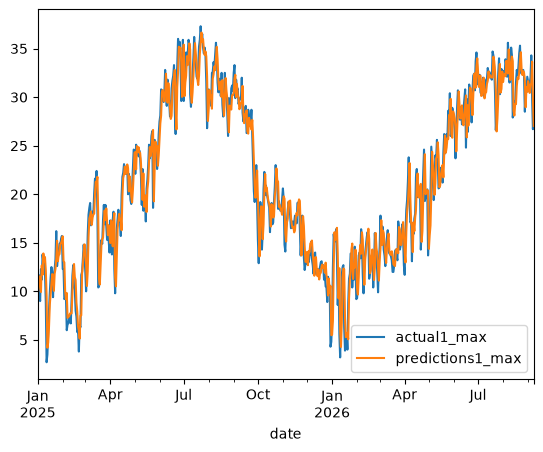

In [496]:
combined1_max.plot()
error1_max

2.1899339364355748

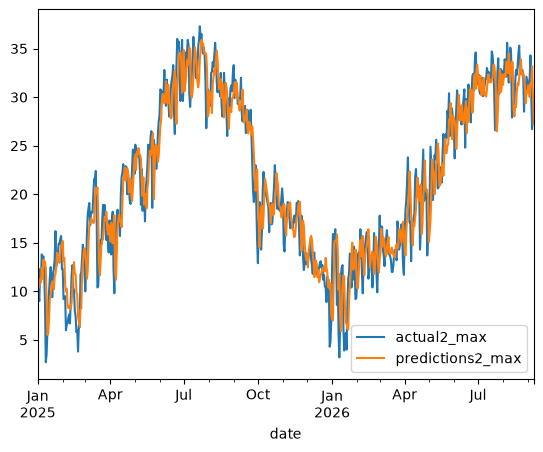

In [497]:
combined2_max.plot()
error2_max

2.4377798071507546

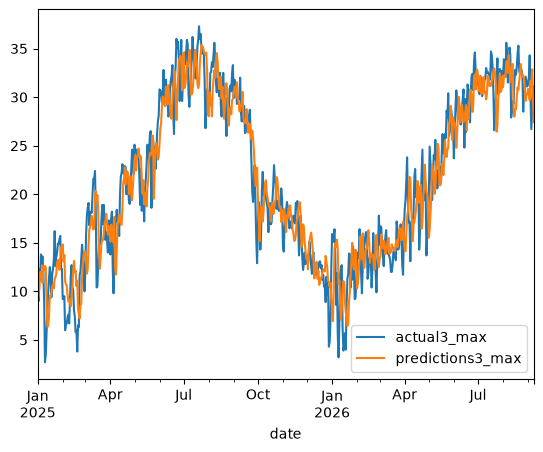

In [498]:
combined3_max.plot()
error3_max

2.5376521686243096

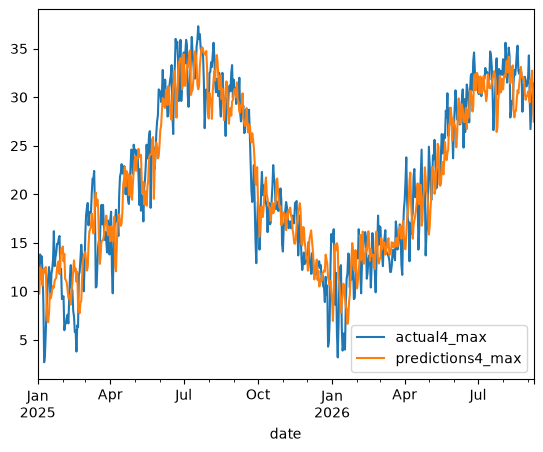

In [499]:
combined4_max.plot()
error4_max

2.6591940905661002

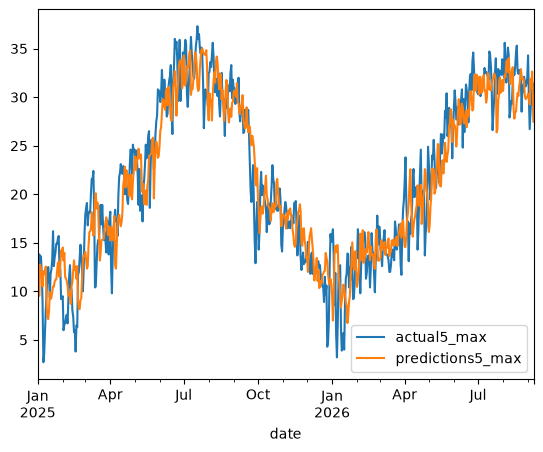

In [500]:
combined5_max.plot()
error5_max

2.7267388229955043

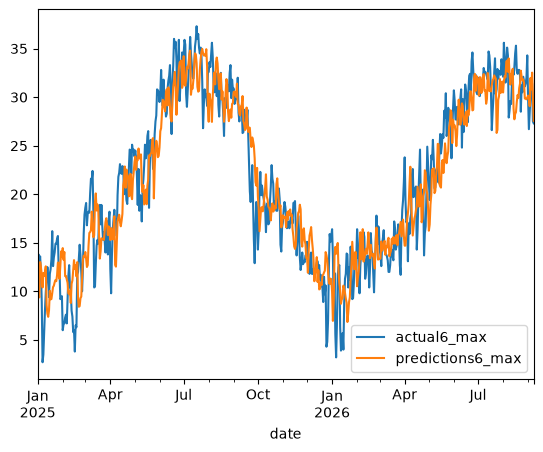

In [501]:
combined6_max.plot()
error6_max

2.7402517317852935

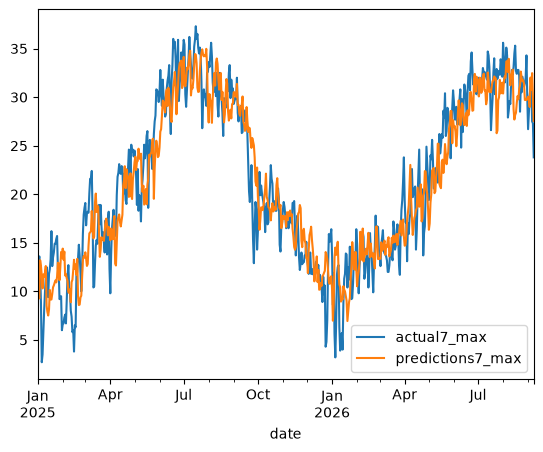

In [502]:
combined7_max.plot()
error7_max

1.1006398160835098

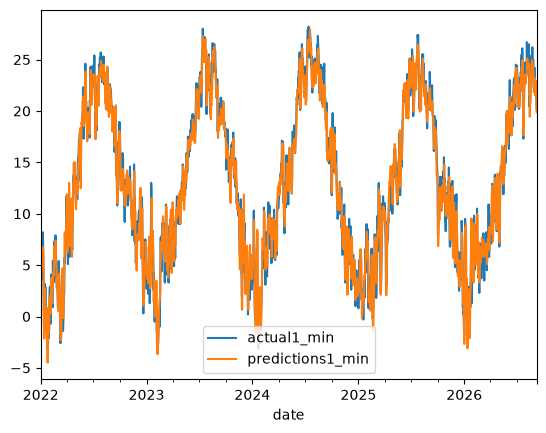

In [503]:
#Best results
predictors_min = ["temp_c_max", "temp_c_min", "temp_c_avg", "humidity_max", "humidity_min", "humidity_avg"]
error1_min, score1_min, combined1_min, error2_min, score2_min, combined2_min, error3_min, score3_min, combined3_min, error4_min, score4_min, combined4_min, error5_min, score5_min, combined5_min, error6_min, score6_min, combined6_min, error7_min, score7_min, combined7_min =create_prediction_min (predictors_min, core_weather, reg1_min, reg2_min, reg3_min, reg4_min, reg5_min, reg6_min, reg7_min)
combined1_min.plot()
error1_min

In [504]:
bundle = {
    "max": [reg1_max, reg2_max, reg3_max, reg4_max, reg5_max, reg6_max, reg7_max],
    "predictors_max": predictors,
    "min": [reg1_min, reg2_min, reg3_min, reg4_min, reg5_min, reg6_min, reg7_min],
    "predictors_min": predictors_min,
}
joblib.dump(bundle, "../models/ridge_v1.joblib")

['../models/ridge_v1.joblib']